# 03 · TenSEAL encrypted inference
Encrypt a few FER2013 samples and run the Packed (im2col) TenSEAL demo pipeline.
This uses the FHE-friendly CNN architecture (Conv -> Square -> FC -> Square -> FC).


### 블록 1 · 의존성 임포트
TenSEAL 컨텍스트 생성기와 암호화 추론 헬퍼, 시각화용 Matplotlib을 불러옵니다.


In [1]:
import sys
from pathlib import Path

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Python path prepared with project root: {PROJECT_ROOT}')

# 코드 변경 후 커널 재시작 또는 모듈 리로드 필요
import importlib
import he.tenseal_context
import models.fhe_cnn
import he.fhe_inference

importlib.reload(he.tenseal_context)
importlib.reload(models.fhe_cnn)
importlib.reload(he.fhe_inference)
print("✅ 모듈 리로드 완료 (tenseal_context, models.fhe_cnn, he.fhe_inference)")

Python path prepared with project root: /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion
✅ 모듈 리로드 완료 (tenseal_context, models.fhe_cnn, he.fhe_inference)
✅ 모듈 리로드 완료 (tenseal_context, models.fhe_cnn, he.fhe_inference)


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from he.tenseal_context import create_context
from he.fhe_inference import encrypted_inference_demo


### 블록 2 · 테스트 데이터 로딩
전처리된 테스트 이미지를 메모리에 불러와 샘플 개수를 확인합니다.


In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
test_images = torch.load(DATA_DIR / 'test_images.pt')
test_labels = torch.load(DATA_DIR / 'test_labels.pt')
print('Loaded test tensors:', test_images.shape)


Loaded test tensors: torch.Size([3589, 1, 48, 48])


### 블록 3 · 암호화 추론 실행
CKKS 컨텍스트를 만들고 선택한 샘플들에 대해 이미지 출력과 `encrypted_inference_demo` 호출을 반복합니다.


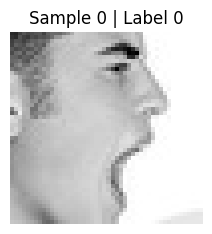

[INFO] Loading model weights from /Users/hyunwookkim/Documents/study/25y2s/보안프로젝트설계/프로젝트/프로토타입/learning_test_01/fhe_emotion/models/fhe_cnn_fer2013.pt
[INFO] Using packed TenSEAL runner for inference
[INFO] Using packed TenSEAL runner for inference
[INFO] Plain inference complete
[INFO] ▶ Packed Conv1 시작
[INFO] Plain inference complete
[INFO] ▶ Packed Conv1 시작
[INFO]     • 출력 채널 1/16 누적 시작
[INFO]     • 출력 채널 1/16 누적 시작
[INFO]         - 입력 채널 1/1 처리
[INFO]         - 입력 채널 1/1 처리


AttributeError: 'CKKSVector' object has no attribute 'rescale_to_next'

In [ ]:
# TenSEAL CKKS 컨텍스트를 한 번만 생성해 여러 샘플 추론에 재사용합니다.
context = create_context()
# 살펴볼 테스트 인덱스를 정의합니다.
sample_indices = [0, 1, 2]
records = []  # 평문/암호문 결과를 누적해 비교하기 위한 리스트
for idx in sample_indices:
    # 1) 원본 얼굴 이미지를 시각화하여 현재 추정 대상이 무엇인지 확인합니다.
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    ax.imshow(test_images[idx, 0], cmap='gray')
    ax.set_title(f'Sample {idx} | Label {int(test_labels[idx])}')
    ax.axis('off')
    plt.show()
    # 2) 동일한 컨텍스트로 암호화 추론을 실행합니다. (Packed TenSEAL 러너 사용)
    result = encrypted_inference_demo(context=context, sample_index=idx, use_packed=True)
    records.append(result)
    # 3) 로그 외에 노트북 셀에서도 바로 비교해볼 수 있도록 dict 전체를 출력합니다.
    print(result)
# 4) 마지막으로 모든 결과를 리스트 형태로 반환해 추가 분석에 활용할 수 있게 합니다.
records
